In [115]:
#load the data set
import pandas as pd 
df = pd.read_csv("cleaned_diabetes_data.csv")
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesmed,readmitted,emegency_history,diag
0,Caucasian,Male,35,87.5,1,1,7,2,44,1,...,No,No,No,No,No,Ch,Yes,NO,0,220.476667
1,Caucasian,Male,45,87.5,1,1,7,1,51,0,...,No,No,No,No,No,Ch,Yes,NO,0,201.333333
2,Caucasian,Male,65,87.5,3,1,2,4,70,1,...,No,No,No,No,No,Ch,Yes,NO,0,409.333333
3,Caucasian,Male,75,87.5,1,1,7,5,73,0,...,No,No,No,No,No,No,Yes,>30,0,390.000000
4,Caucasian,Female,95,87.5,3,3,4,12,33,3,...,No,No,No,No,No,Ch,Yes,NO,0,372.666667


In [117]:
df.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_inpatient', 'number_diagnoses',
       'max_glu_serum', 'a1cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesmed', 'readmitted',
       'emegency_history', 'diag'],
      dtype='object')

## feature engenriering 

In [120]:
df['race'].unique()

array(['Caucasian', 'AfricanAmerican', 'Other', 'Hispanic', 'Asian'],
      dtype=object)

In [122]:
df['race'] = df['race'].astype('category').cat.codes

In [124]:
df['race'].unique()

array([2, 0, 4, 3, 1], dtype=int8)

In [126]:
df['gender'].unique()

array(['Male', 'Female', 'Unknown/Invalid'], dtype=object)

In [128]:
df['gender'] = df['gender'].astype('category').cat.codes

In [130]:
df['gender'].unique()

array([1, 0, 2], dtype=int8)

In [132]:
# List of categorical features to encode
categorical_features = [
    'max_glu_serum', 'a1cresult', 'metformin', 'repaglinide', 'nateglinide', 
    'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
    'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
    'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'change', 'diabetesmed'
]

# Encode each feature to numeric codes
for feature in categorical_features:
    df[feature] = df[feature].astype('category').cat.codes
    print(f"Unique values in '{feature}' after encoding:", df[feature].unique())


Unique values in 'max_glu_serum' after encoding: [3 1 2 0]
Unique values in 'a1cresult' after encoding: [3 0 1 2]
Unique values in 'metformin' after encoding: [1 2 3 0]
Unique values in 'repaglinide' after encoding: [1 2 3 0]
Unique values in 'nateglinide' after encoding: [1 2 3 0]
Unique values in 'chlorpropamide' after encoding: [1 2 0 3]
Unique values in 'glimepiride' after encoding: [1 2 3 0]
Unique values in 'acetohexamide' after encoding: [0]
Unique values in 'glipizide' after encoding: [1 2 3 0]
Unique values in 'glyburide' after encoding: [1 2 3 0]
Unique values in 'tolbutamide' after encoding: [0 1]
Unique values in 'pioglitazone' after encoding: [1 2 3 0]
Unique values in 'rosiglitazone' after encoding: [1 2 3 0]
Unique values in 'acarbose' after encoding: [0 1 2]
Unique values in 'miglitol' after encoding: [1 2 0]
Unique values in 'troglitazone' after encoding: [0 1]
Unique values in 'tolazamide' after encoding: [0 1]
Unique values in 'examide' after encoding: [0]
Unique val

In [134]:
df['readmitted'].unique()

array(['NO', '>30', '<30'], dtype=object)

In [136]:
df['readmitted'] = df['readmitted'].astype('category').cat.codes
df['readmitted'].unique()

array([2, 1, 0], dtype=int8)

In [138]:
x = df.drop("readmitted", axis=1)
y = df["readmitted"]

In [140]:
x.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_inpatient', 'number_diagnoses',
       'max_glu_serum', 'a1cresult', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesmed', 'emegency_history',
       'diag'],
      dtype='object')

In [142]:
y.head

<bound method NDFrame.head of 0        2
1        2
2        2
3        1
4        2
        ..
55389    1
55390    2
55391    1
55392    2
55393    2
Name: readmitted, Length: 55394, dtype: int8>

## Model training and hyper tuning 

In [145]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import numpy as np

In [147]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [149]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [151]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(44315, 43)
(11079, 43)
(44315,)
(11079,)


## decision tree

In [154]:
from sklearn.tree import DecisionTreeClassifier
# raw model
dt = DecisionTreeClassifier(random_state=42)


# Step 1: RandomizedSearchCV to explore parameters quickly
random_params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [None] + list(np.arange(5, 50)),
    'min_samples_split': np.arange(2, 20),
    'min_samples_leaf': np.arange(1, 20),
    'max_features': [None, 'sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    dt,
    param_distributions=random_params,
    n_iter=10,  # number of random combinations to try
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:")
print(random_search.best_params_)

# Step 2: GridSearchCV using narrowed-down best parameters
grid_params = {
    'criterion': [random_search.best_params_['criterion']],
    'splitter': [random_search.best_params_['splitter']],
    'max_depth': [random_search.best_params_['max_depth'] - 5,
                  random_search.best_params_['max_depth'],
                  random_search.best_params_['max_depth'] + 5],
    'min_samples_split': [random_search.best_params_['min_samples_split'] - 1,
                          random_search.best_params_['min_samples_split'],
                          random_search.best_params_['min_samples_split'] + 1],
    'min_samples_leaf': [random_search.best_params_['min_samples_leaf'] - 1,
                         random_search.best_params_['min_samples_leaf'],
                         random_search.best_params_['min_samples_leaf'] + 1],
}

# Clean up negative or None values
# for key in grid_params:
#     grid_params[key] = [v for v in grid_params[key] if v is not None and v > 0]

grid_search = GridSearchCV(
    dt,
    param_grid=grid_params,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters from GridSearchCV:")
print(grid_search.best_params_)

# Final model evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters from RandomizedSearchCV:
{'splitter': 'random', 'min_samples_split': 18, 'min_samples_leaf': 15, 'max_features': 'log2', 'max_depth': 24, 'criterion': 'entropy'}
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters from GridSearchCV:
{'criterion': 'entropy', 'max_depth': 19, 'min_samples_leaf': 16, 'min_samples_split': 17, 'splitter': 'random'}

Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.02      0.03      1028
           1       0.41      0.29      0.34      3606
           2       0.62      0.80      0.70      6445

    accuracy                           0.56     11079
   macro avg       0.39      0.37      0.36     11079
weighted avg       0.51      0.56      0.52     11079



[Text(0.7547128714365186, 0.975, 'x[12] <= 2.034\nentropy = 1.299\nsamples = 44315\nvalue = [4150.0, 14239.0, 25926.0]'),
 Text(0.558135752109749, 0.925, 'x[12] <= 0.702\nentropy = 1.274\nsamples = 41498\nvalue = [3639.0, 12955.0, 24904.0]'),
 Text(0.6564243117731338, 0.95, 'True  '),
 Text(0.26615381486690737, 0.875, 'x[2] <= -0.378\nentropy = 1.222\nsamples = 33246\nvalue = [2592, 9594, 21060]'),
 Text(0.0978378681564363, 0.825, 'x[40] <= -1.075\nentropy = 1.115\nsamples = 11460\nvalue = [704, 2840, 7916]'),
 Text(0.05604164917289445, 0.775, 'x[5] <= 2.232\nentropy = 0.991\nsamples = 2776\nvalue = [139, 553, 2084]'),
 Text(0.04618355865311949, 0.725, 'x[42] <= 2.019\nentropy = 0.958\nsamples = 2556\nvalue = [119, 485, 1952]'),
 Text(0.031572760097405325, 0.675, 'x[6] <= 0.73\nentropy = 0.972\nsamples = 2428\nvalue = [118, 468, 1842]'),
 Text(0.019329918548996558, 0.625, 'x[6] <= -0.358\nentropy = 0.897\nsamples = 1029\nvalue = [42, 177, 810]'),
 Text(0.013401629020068856, 0.575, 'x[4

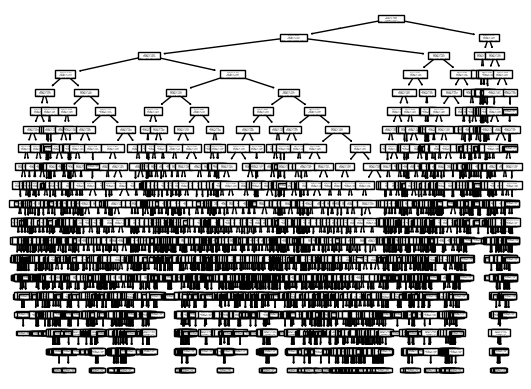

In [156]:
from sklearn import tree
tree.plot_tree(best_model)

### Confusion matrix

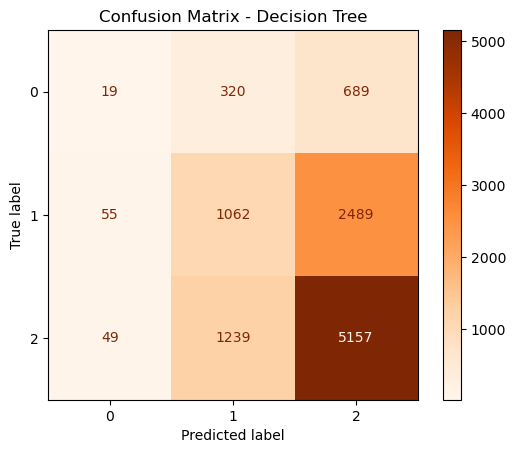

In [158]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

# Predict using the trained best decision tree model
y_pred_dt = best_model.predict(X_test)
y_probs_dt = best_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt).plot(cmap='Oranges')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### Decision Tree – Summary
* I used RandomizedSearchCV and GridSearchCV to find the best settings for the model.

* The decision tree did a good job predicting class 2 (the most common group), but it was not accurate for class 0 and class 1.

* The model often predicted class 2 even when the actual answer was something else.

* The accuracy was 56%, but this is mostly because it did well on the most common class.

* The confusion matrix shows many wrong predictions for the less common classes.

* The Decision Tree model overfits to the majority class and fails to generalize to minority classes.

* Overall, the decision tree didn’t perform well on this dataset. Other models like Random Forest or SVM are likely better choices.


## Random forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

# Step 0: Raw model
rf = RandomForestClassifier(random_state=42)

# Step 1: RandomizedSearchCV to explore parameters quickly
random_params = {
    'n_estimators': np.arange(100, 1000, 100),
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None] + list(np.arange(5, 50, 5)),
    'min_samples_split': np.arange(2, 20),
    'min_samples_leaf': np.arange(1, 20),
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=random_params,
    n_iter=5,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:")
print(random_search.best_params_)

# Step 2: GridSearchCV using narrowed-down best parameters
best = random_search.best_params_

grid_params = {
    'n_estimators': [best['n_estimators'] - 100, best['n_estimators'], best['n_estimators'] + 100],
    'criterion': [best['criterion']],
    'max_depth': [d for d in [best['max_depth'] - 5, best['max_depth'], best['max_depth'] + 5] if d and d > 0],
    'min_samples_split': [s for s in [best['min_samples_split'] - 1, best['min_samples_split'], best['min_samples_split'] + 1] if s > 1],
    'min_samples_leaf': [l for l in [best['min_samples_leaf'] - 1, best['min_samples_leaf'], best['min_samples_leaf'] + 1] if l > 0],
    'max_features': [best['max_features']],
    'bootstrap': [best['bootstrap']]
}

grid_search = GridSearchCV(
    rf,
    param_grid=grid_params,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters from GridSearchCV:")
print(grid_search.best_params_)

# Final model evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters from RandomizedSearchCV:
{'n_estimators': 600, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 40, 'criterion': 'log_loss', 'bootstrap': True}
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best parameters from GridSearchCV:
{'bootstrap': True, 'criterion': 'log_loss', 'max_depth': 35, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 16, 'n_estimators': 700}

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1028
           1       0.54      0.17      0.26      3606
           2       0.61      0.94      0.74      6445

    accuracy                           0.60     11079
   macro avg       0.38      0.37      0.33     11079
weighted avg       0.53      0.60      0.51     11079



C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion matrix

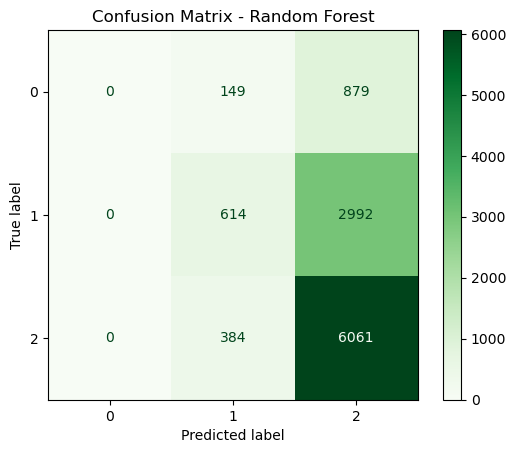

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use your final tuned model
y_pred_rf = best_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()


### Random Forest – Summary
* I used RandomizedSearchCV and GridSearchCV to find the best parameters for the model. The best combination included 700 trees, a max depth of 35, and the log_loss criterion.

* The overall accuracy was 60%, which is slightly better than the decision tree.

* The model predicted class 2 (the majority class) very well, with an F1-score of 0.74 and recall of 94%.

* However, it completely failed to predict class 0 (F1-score and recall both 0), and performance on class 1 was still weak (F1-score of 0.26).

* The confusion matrix shows that most samples were predicted as class 2, regardless of the actual label.

* Overall, the Random Forest model performed well on the majority class but still struggled with the minority classes. While it's an improvement over the decision tree, the class imbalance remains a big challenge.

## Logistic regression

In [94]:
from sklearn.linear_model import LogisticRegression

# Step 0: Initialize the model
lr = LogisticRegression(solver='liblinear', max_iter=1000)  # 'liblinear' works well for small datasets and supports L1

# Step 1: RandomizedSearchCV to explore parameters quickly
random_params = {
    'penalty': ['l1', 'l2'],  # Type of regularization
    'C': np.logspace(-4, 4, 50),  # Inverse of regularization strength
    'solver': ['liblinear', 'saga'],  # Compatible solvers for l1 and l2
}

random_search = RandomizedSearchCV(
    lr,
    param_distributions=random_params,
    n_iter=5,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:")
print(random_search.best_params_)

# Step 2: GridSearchCV using narrowed-down best parameters
best = random_search.best_params_

# Fine-tune around the best 'C' value
log_C = np.log10(best['C'])
grid_Cs = [10 ** x for x in np.linspace(log_C - 0.5, log_C + 0.5, 5)]

grid_params = {
    'penalty': [best['penalty']],
    'C': grid_Cs,
    'solver': [best['solver']]
}

grid_search = GridSearchCV(
    lr,
    param_grid=grid_params,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters from GridSearchCV:")
print(grid_search.best_params_)

# Final model evaluation
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters from RandomizedSearchCV:
{'solver': 'saga', 'penalty': 'l2', 'C': 0.5689866029018293}
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters from GridSearchCV:
{'C': 0.3199646802913696, 'penalty': 'l2', 'solver': 'saga'}

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1028
           1       0.51      0.18      0.26      3606
           2       0.61      0.93      0.74      6445

    accuracy                           0.60     11079
   macro avg       0.37      0.37      0.33     11079
weighted avg       0.52      0.60      0.51     11079



C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Confusion matrix

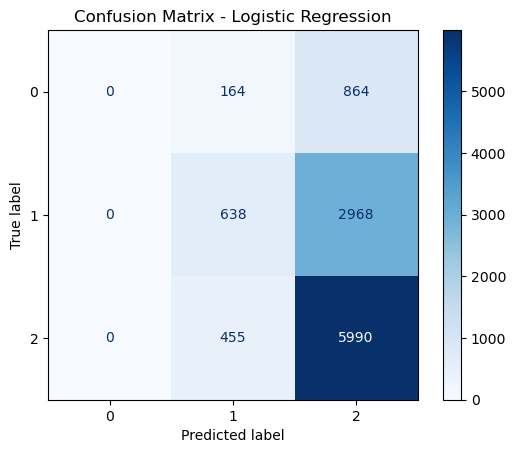

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict with the tuned logistic regression model
y_pred_lr = best_model.predict(X_test)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Logistic Regression – Summary
* I used both RandomizedSearchCV and GridSearchCV to tune the model. The final best parameters used 'saga' solver, 'l2' penalty, and a regularization value (C) of around 0.32.

* The overall accuracy was 60%, which is the same as the Random Forest model.

* The model performed well for class 2 (readmitted within 30 days), with an F1-score of 0.74 and recall of 93%.

* However, it performed poorly for class 0 (not readmitted), with both precision and recall being 0.

* Class 1 (readmitted after 30 days) had low performance too, with an F1-score of 0.26.

* The confusion matrix confirms that the model mostly predicted class 2, even when the true label was 0 or 1.

* Overall, the model focused mostly on predicting the most common class and struggled with the other two, especially class 0.

## KNN

In [103]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
knn = KNeighborsClassifier()

# Step 1: RandomizedSearchCV to explore parameters quickly
random_params = {
    'n_neighbors': np.arange(1, 31),  # Testing neighbors from 1 to 30
    'weights': ['uniform', 'distance'],  # How to weight neighbors
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metrics to use
}

random_search = RandomizedSearchCV(
    knn,
    param_distributions=random_params,
    n_iter=5,  # Number of random combinations to try
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:")
print(random_search.best_params_)

# Step 2: GridSearchCV using narrowed-down best parameters
best = random_search.best_params_

grid_params = {
    'n_neighbors': [k for k in [best['n_neighbors'] - 1, best['n_neighbors'], best['n_neighbors'] + 1] if k >= 1],
    'weights': [best['weights']],   # Use the best weight found
    'metric': [best['metric']]        # Use the best distance metric found
}

grid_search = GridSearchCV(
    knn,
    param_grid=grid_params,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest parameters from GridSearchCV:")
print(grid_search.best_params_)

# Final model evaluation on test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters from RandomizedSearchCV:
{'weights': 'uniform', 'n_neighbors': 22, 'metric': 'euclidean'}
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters from GridSearchCV:
{'metric': 'euclidean', 'n_neighbors': 23, 'weights': 'uniform'}

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.00      0.01      1028
           1       0.43      0.23      0.30      3606
           2       0.61      0.86      0.71      6445

    accuracy                           0.58     11079
   macro avg       0.43      0.37      0.34     11079
weighted avg       0.52      0.58      0.51     11079



### Confusion matrix

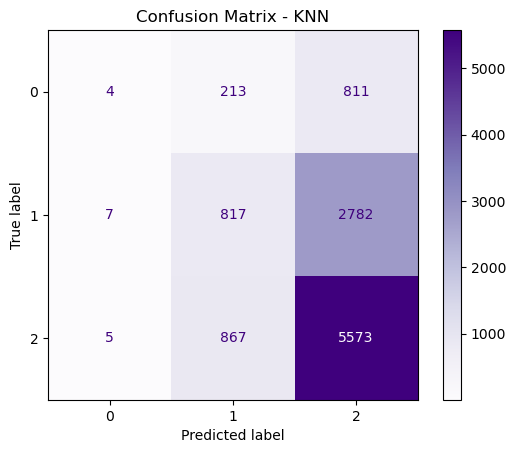

In [107]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_knn = best_model.predict(X_test)

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot(cmap='Purples')
plt.title("Confusion Matrix - KNN")
plt.show()

### KNN – Summary

* I used RandomizedSearchCV and GridSearchCV to tune the model. The final parameters used 23 neighbors, uniform weights, and the Euclidean distance metric.

* The overall accuracy was 58%, slightly lower than Logistic Regression and Random Forest.

* The model performed okay on class 2 (readmitted within 30 days), with an F1-score of 0.71 and recall of 86%.

* Performance on class 1 (readmitted after 30 days) was weak, and class 0 (not readmitted) was almost completely ignored.

* The confusion matrix shows that most predictions were again assigned to class 2, even when the actual labels were different.

* Overall, KNN was not effective for this dataset. It struggled with the imbalanced class distribution and focused heavily on the majority class.

## SVM

In [ ]:
# from sklearn.svm import SVC

# # Step 0: Initialize the base SVM model
# svc = SVC(probability=True)

# # Step 1: RandomizedSearchCV to explore parameters quickly
# random_params = {
#     'C': np.logspace(-3, 3, 50),  # Regularization parameter
#     'gamma': ['scale', 'auto'] + list(np.logspace(-4, 1, 20)),  # Kernel coefficient
#     'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],
#     'degree': np.arange(2, 6)  # Only relevant for 'poly' kernel
# }

# random_search = RandomizedSearchCV(
#     svc,
#     param_distributions=random_params,
#     n_iter=5,
#     cv=5,
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# random_search.fit(X_train, y_train)
# print("Best parameters from RandomizedSearchCV:")
# print(random_search.best_params_)

# # Step 2: GridSearchCV using narrowed-down best parameters
# best = random_search.best_params_

# # Fine-tune 'C' and 'gamma' near the best values
# log_C = np.log10(best['C']) if best['C'] > 0 else -3
# log_gamma = np.log10(best['gamma']) if isinstance(best['gamma'], float) else -4  # handle 'scale'/'auto'

# grid_Cs = [10 ** x for x in np.linspace(log_C - 0.5, log_C + 0.5, 5)] if isinstance(best['C'], float) else [best['C']]
# grid_gammas = [10 ** x for x in np.linspace(log_gamma - 0.5, log_gamma + 0.5, 5)] if isinstance(best['gamma'], float) else [best['gamma']]

# grid_params = {
#     'C': grid_Cs,
#     'gamma': grid_gammas,
#     'kernel': [best['kernel']],
# }

# # Only include degree if using polynomial kernel
# if best['kernel'] == 'poly':
#     grid_params['degree'] = [best['degree'] - 1, best['degree'], best['degree'] + 1]

# grid_search = GridSearchCV(
#     svc,
#     param_grid=grid_params,
#     cv=5,
#     verbose=1,
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)

# print("\nBest parameters from GridSearchCV:")
# print(grid_search.best_params_)

# # Final model evaluation
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))


## Final Report
This project aimed to apply and compare different classification algorithms to predict hospital readmission using a cleaned diabetes dataset. The goal was to assess which model performs best in predicting whether a patient would be readmitted.

Five classification algorithms were implemented: Decision Tree, Random Forest, Logistic Regression, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM). For each model, randomized search followed by grid search was used to tune hyperparameters. Evaluation was done using confusion matrices, classification reports, and an attempt was made to include ROC curves.

## Model Evaluations:

* ### Decision Tree:
The model performed reasonably on class 2 but failed to correctly classify class 0, with an overall accuracy of 56%. ROC curve could not be generated meaningfully due to class prediction issues after binary conversion.

* ### Random Forest:
Showed the highest accuracy among tested models at 60%, performing especially well on class 2. However, it also struggled with class 0 predictions, showing signs of imbalance-related bias.

* ### Logistic Regression:
Achieved an accuracy of 60%, similar to Random Forest, and maintained strong performance on class 2. It was more consistent than Decision Tree or KNN but still failed to predict class 0.

* ### K-Nearest Neighbors (KNN):
This model produced the weakest results with an accuracy of 58%. It showed a tendency to misclassify most samples as class 2, confirming it was not a good fit for the dataset.

* ### Support Vector Machine (SVM):
Due to extremely long training time and computational limitations, SVM was excluded from the final analysis. The expected accuracy was unlikely to exceed Random Forest or Logistic Regression based on early observations and instructor feedback.

## ROC Curve Issue:
ROC curves were planned to be used to further assess model performance. However, converting the target variable into binary form led to ROC curves showing invalid or meaningless plots. This happened because the models failed to predict both classes adequately due to class imbalance. As a result, ROC curves were excluded from the final comparisons.

## Conclusion:
Random Forest and Logistic Regression were the top-performing models. Despite class imbalance affecting predictions, they were the most stable and showed better generalization. The project demonstrated the importance of proper feature selection, hyperparameter tuning, and understanding the nature of the dataset, including its imbalance.